### Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set(style="whitegrid")

### Load Dataset

In [5]:
# Load dataset
df = pd.read_csv("../data/processed/state_factors_nfhs.csv")

# Preview
df.head()

,state,immunization,stunting,wasting,female_literacy,sanitation
0,Andaman & Nicobar Islands,77.78,22.47,15.99,83.52,87.97
1,Andhra Pradesh,73.02,31.16,16.06,65.57,77.26
2,Arunachal Pradesh,64.87,27.98,13.08,71.16,82.88
3,Assam,66.44,35.29,21.73,78.19,68.55
4,Bihar,70.96,42.94,22.89,61.10,49.40


### Shape + Info

In [6]:
print("Shape:", df.shape)
df.info()

Shape: (36, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   state            36 non-null     object 
 1   immunization     36 non-null     float64
 2   stunting         36 non-null     float64
 3   wasting          36 non-null     float64
 4   female_literacy  36 non-null     float64
 5   sanitation       36 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.8+ KB


### Missing Values

In [7]:
df.isnull().sum()

state              0
immunization       0
stunting           0
wasting            0
female_literacy    0
sanitation         0
dtype: int64

### Statistical Summary

In [8]:
df.describe()

,immunization,stunting,wasting,female_literacy,sanitation
count,36.000000,36.000000,36.000000,36.000000,36.000000
mean,68.625278,31.222500,16.853889,77.012222,76.321667
std,38.315385,6.227565,4.425536,9.275111,12.604952
min,-86.140000,19.980000,8.410000,60.940000,42.320000
25%,70.625000,26.587500,13.155000,69.872500,68.700000
50%,76.995000,31.085000,17.370000,76.970000,76.500000
75%,81.955000,35.252500,19.235000,83.817500,84.992500
max,94.880000,46.540000,25.600000,95.500000,99.800000


### Check for Duplicates

In [9]:
df.duplicated().sum()

0

In [10]:
df['state'].nunique()

36

### Correlation Matrix

In [11]:
# Correlation matrix (exclude state column)
corr = df.drop(columns=['state']).corr()

corr

,immunization,stunting,wasting,female_literacy,sanitation
immunization,1.000000,0.049041,0.236768,-0.359030,-0.349181
stunting,0.049041,1.000000,0.576558,-0.435126,-0.462040
wasting,0.236768,0.576558,1.000000,-0.442774,-0.453521
female_literacy,-0.359030,-0.435126,-0.442774,1.000000,0.709173
sanitation,-0.349181,-0.462040,-0.453521,0.709173,1.000000


### Heatmap Visualization

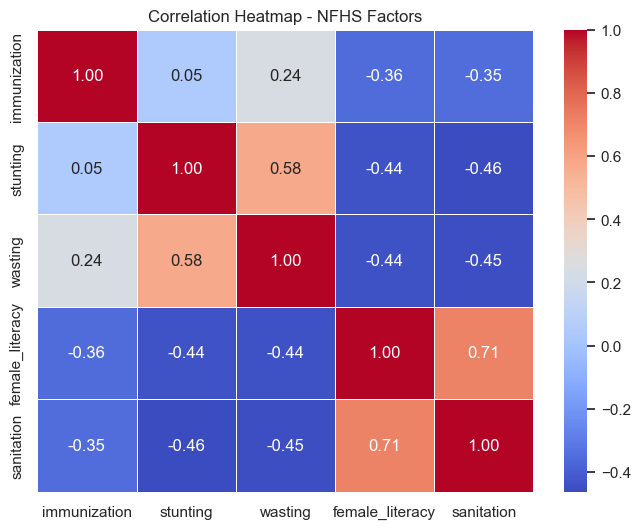

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap - NFHS Factors")
plt.savefig("../outputs/figures/heatmaps/nfhs_correlation_heatmap_v1.png", dpi=300, bbox_inches='tight')
plt.show()

### Worst States (High Risk)

In [13]:
# Worst states based on stunting
worst_stunting = df.sort_values(by='stunting', ascending=False).head(10)

# Worst states based on wasting
worst_wasting = df.sort_values(by='wasting', ascending=False).head(10)

worst_stunting, worst_wasting

(                                     state  immunization  stunting  wasting  \
 21                               Meghalaya         63.80     46.54    12.10   
 4                                    Bihar         70.96     42.94    22.89   
 33                           Uttar Pradesh         69.62     39.71    17.32   
 13                               Jharkhand         73.91     39.58    22.41   
 7   Dadra and Nagar Haveli & Daman and Diu         94.88     39.42    21.59   
 9                                  Gujarat         76.34     39.02    25.10   
 18                          Madhya Pradesh         77.10     35.67    18.95   
 14                               Karnataka         84.08     35.43    19.52   
 3                                    Assam         66.44     35.29    21.73   
 19                              Maharastra         73.46     35.24    25.60   
 
     female_literacy  sanitation  
 21            85.85       82.88  
 4             61.10       49.40  
 33          

### Plot 1 — Worst States (Stunting)

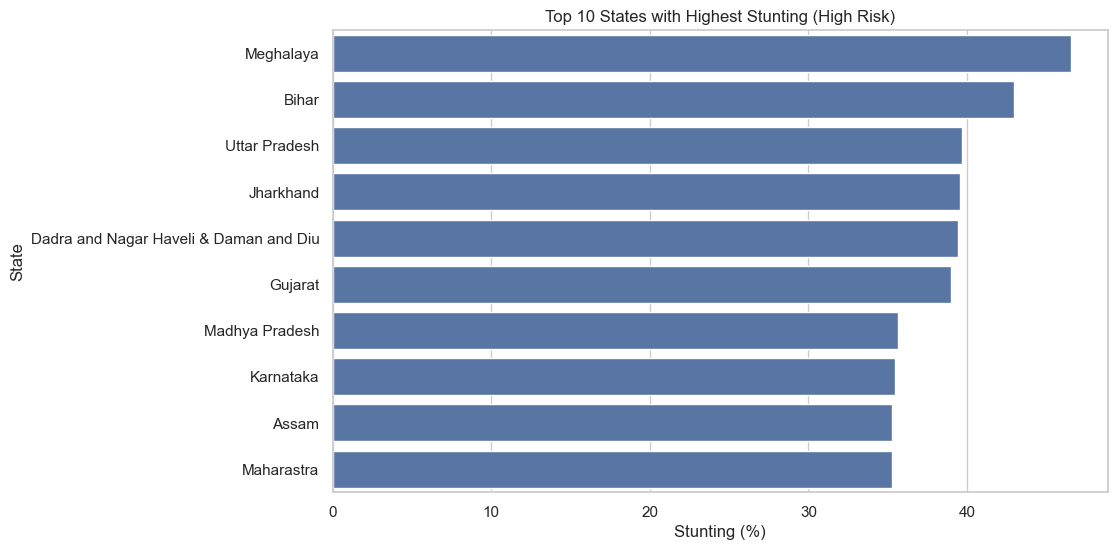

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=worst_stunting,
    x='stunting',
    y='state'
)

plt.title("Top 10 States with Highest Stunting (High Risk)")
plt.xlabel("Stunting (%)")
plt.ylabel("State")

plt.savefig("../outputs/figures/comparisons/nfhs_stunting_worst_states_v1.png", dpi=300, bbox_inches='tight')

plt.show()

### Plot 2 — Worst States (Wasting)

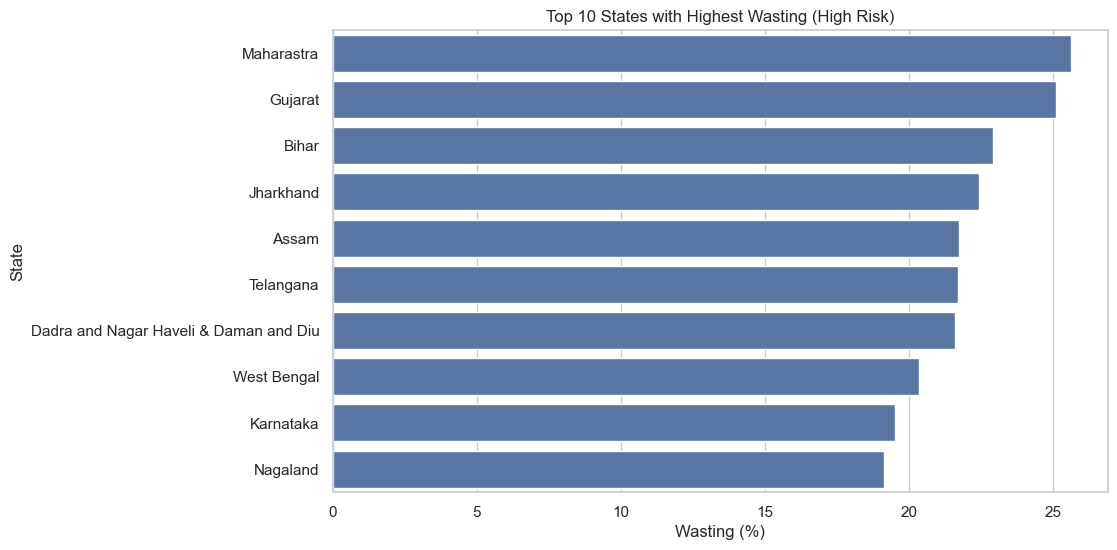

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=worst_wasting,
    x='wasting',
    y='state'
)

plt.title("Top 10 States with Highest Wasting (High Risk)")
plt.xlabel("Wasting (%)")
plt.ylabel("State")

plt.savefig("../outputs/figures/comparisons/nfhs_wasting_worst_states_v1.png", dpi=300, bbox_inches='tight')

plt.show()

### Best States

In [16]:
# Best states based on immunization
best_immunization = df.sort_values(by='immunization', ascending=False).head(10)

best_immunization

,state,immunization,stunting,wasting,female_literacy,sanitation
7,Dadra and Nagar Haveli & Daman and Diu,94.88,39.42,21.59,74.40,65.76
25,Odisha,90.46,31.01,18.06,71.50,60.47
11,Himachal Pradesh,89.25,30.84,17.39,80.95,81.75
30,Tamil Nadu,89.20,25.04,14.61,80.35,72.62
16,Ladakh,88.22,30.53,17.46,67.95,42.32
35,West Bengal,87.81,33.78,20.33,76.79,68.03
12,Jammu & Kashmir,86.22,26.86,18.98,70.07,75.73
14,Karnataka,84.08,35.43,19.52,72.95,74.78
26,Puducherry,82.00,19.98,12.35,84.62,84.93
8,Goa,81.94,25.77,19.12,88.95,87.92


### Plot 3 — Best States (Immunization)

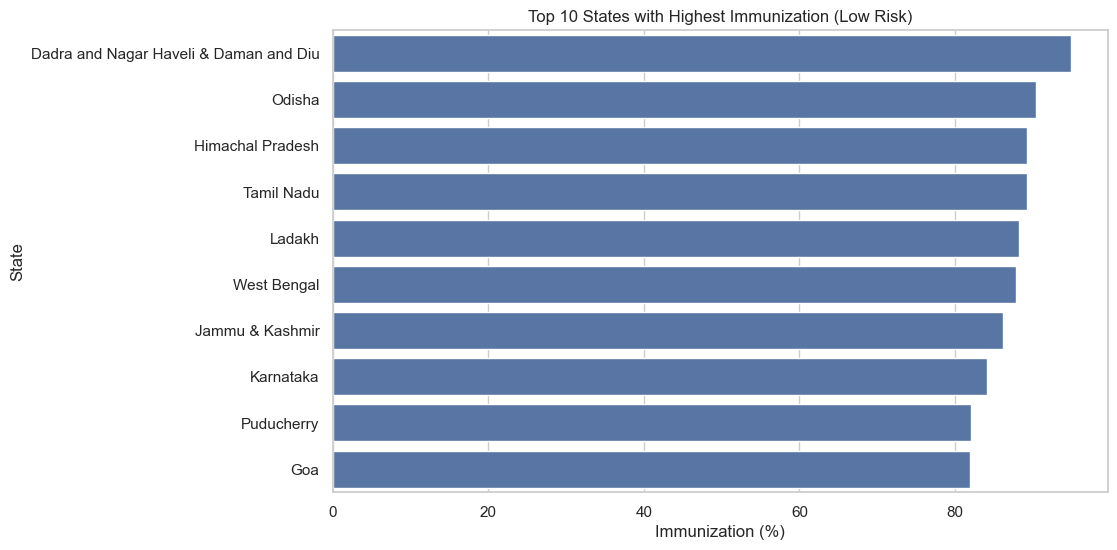

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=best_immunization,
    x='immunization',
    y='state'
)

plt.title("Top 10 States with Highest Immunization (Low Risk)")
plt.xlabel("Immunization (%)")
plt.ylabel("State")

plt.savefig("../outputs/figures/comparisons/nfhs_immunization_best_states_v1.png", dpi=300, bbox_inches='tight')

plt.show()

### Normalize Features

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features = ['immunization', 'stunting', 'wasting', 'female_literacy', 'sanitation']

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,state,immunization,stunting,wasting,female_literacy,sanitation
0,Andaman & Nicobar Islands,0.905535,0.093750,0.440954,0.653356,0.794189
1,Andhra Pradesh,0.879240,0.420934,0.445026,0.133970,0.607864
2,Arunachal Pradesh,0.834217,0.301205,0.271670,0.295718,0.705637
3,Assam,0.842890,0.576431,0.774869,0.499132,0.456333
4,Bihar,0.867860,0.864458,0.842350,0.004630,0.123173


In [19]:
df_scaled['risk_score'] = (
    df_scaled['stunting'] +
    df_scaled['wasting'] +
    (1 - df_scaled['immunization']) +
    (1 - df_scaled['female_literacy']) +
    (1 - df_scaled['sanitation'])
)

In [20]:
df_risk = df_scaled.sort_values(by='risk_score', ascending=False)

df_risk[['state', 'risk_score']].head(10)

,state,risk_score
4,Bihar,3.711145
13,Jharkhand,3.315909
9,Gujarat,2.893218
31,Telangana,2.765128
16,Ladakh,2.757639
33,Uttar Pradesh,2.753691
18,Madhya Pradesh,2.717948
7,Dadra and Nagar Haveli & Daman and Diu,2.701391
19,Maharastra,2.635956
3,Assam,2.552945


### Visualize Risk

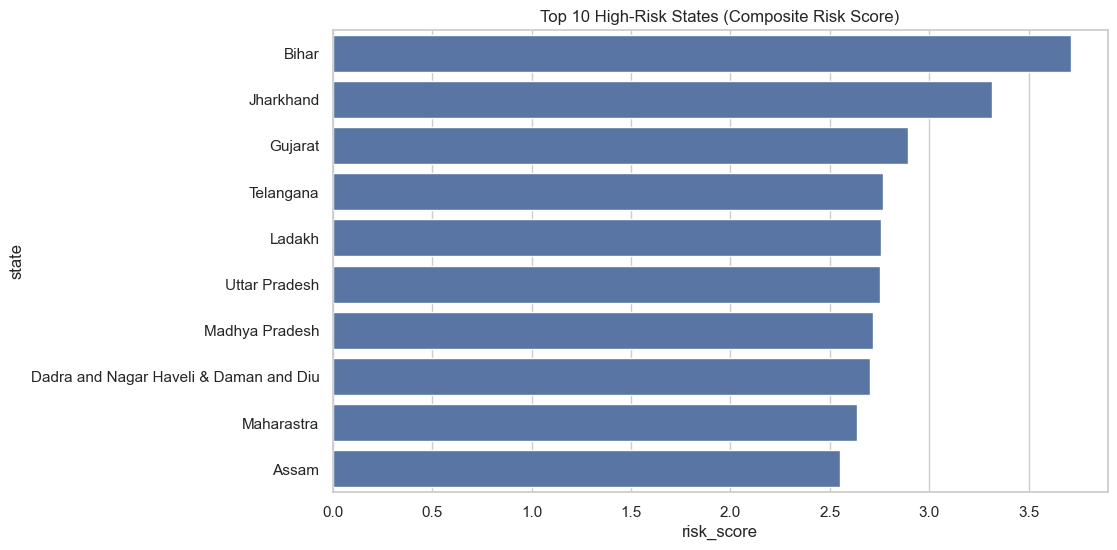

In [21]:
top_risk = df_risk.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_risk,
    x='risk_score',
    y='state'
)

plt.title("Top 10 High-Risk States (Composite Risk Score)")

plt.savefig("../outputs/figures/comparisons/nfhs_risk_score_top_states_v1.png", dpi=300, bbox_inches='tight')

plt.show()

### Weighted Risk Score (Advanced)

In [22]:
df_scaled['weighted_risk_score'] = (
    0.3 * df_scaled['stunting'] +
    0.3 * df_scaled['wasting'] +
    0.15 * (1 - df_scaled['immunization']) +
    0.15 * (1 - df_scaled['female_literacy']) +
    0.1 * (1 - df_scaled['sanitation'])
)

In [23]:
df_weighted = df_scaled.sort_values(by='weighted_risk_score', ascending=False)

df_weighted[['state', 'weighted_risk_score']].head(10)

,state,weighted_risk_score
4,Bihar,0.768852
13,Jharkhand,0.692708
9,Gujarat,0.664725
19,Maharastra,0.607411
7,Dadra and Nagar Haveli & Daman and Diu,0.600396
31,Telangana,0.584453
33,Uttar Pradesh,0.575220
3,Assam,0.558453
18,Madhya Pradesh,0.558065
14,Karnataka,0.518753


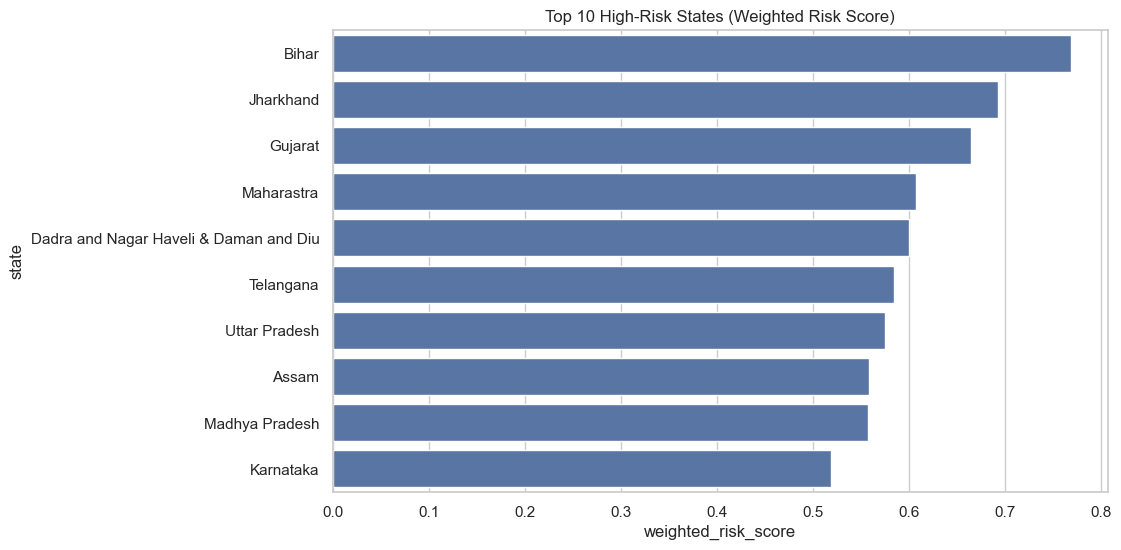

In [24]:
top_weighted = df_weighted.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_weighted,
    x='weighted_risk_score',
    y='state'
)

plt.title("Top 10 High-Risk States (Weighted Risk Score)")

plt.savefig("../outputs/figures/comparisons/nfhs_weighted_risk_score_v1.png", dpi=300, bbox_inches='tight')

plt.show()

### Creating Labels (High / Medium / Low Risk)

In [25]:
# Create risk categories based on weighted score
df_weighted['risk_category'] = pd.qcut(
    df_weighted['weighted_risk_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df_weighted[['state', 'weighted_risk_score', 'risk_category']].head(10)

,state,weighted_risk_score,risk_category
4,Bihar,0.768852,High
13,Jharkhand,0.692708,High
9,Gujarat,0.664725,High
19,Maharastra,0.607411,High
7,Dadra and Nagar Haveli & Daman and Diu,0.600396,High
31,Telangana,0.584453,High
33,Uttar Pradesh,0.575220,High
3,Assam,0.558453,High
18,Madhya Pradesh,0.558065,High
14,Karnataka,0.518753,High


### Prepare Data for ML

In [ ]:
from sklearn.model_selection import train_test_split

# Features
X = df_weighted[['immunization', 'stunting', 'wasting', 'female_literacy', 'sanitation']]

# Target
y = df_weighted['risk_category']

# Split (still useful, but not main evaluation metric for this EDA)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Model

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Evaluate Model

In [33]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.875      0.71428571 1.         1.         0.85714286]
Mean accuracy: 0.8892857142857142


In [34]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

scores_dt = cross_val_score(dt_model, X, y, cv=5)

print("Decision Tree scores:", scores_dt)
print("Mean accuracy:", scores_dt.mean())

Decision Tree scores: [0.875      0.57142857 1.         1.         0.85714286]
Mean accuracy: 0.8607142857142855


### Feature Importance

In [35]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance

,feature,importance
1,stunting,0.400314
2,wasting,0.278989
3,female_literacy,0.136844
4,sanitation,0.123307
0,immunization,0.060547


### Plotting Feature Importance

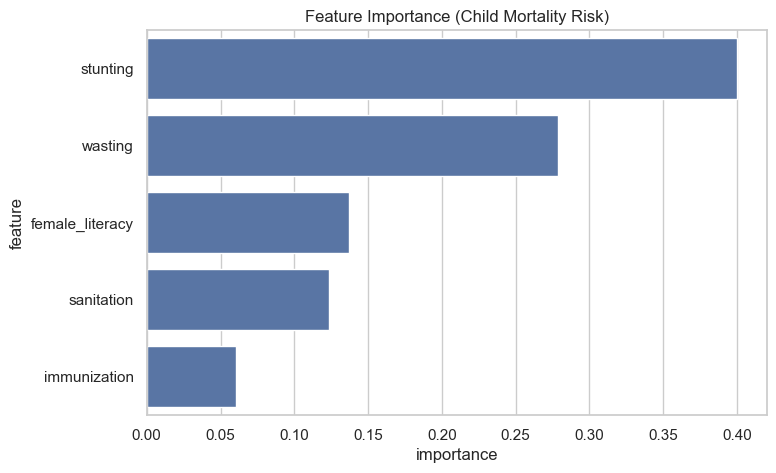

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='importance',
    y='feature'
)

plt.title("Feature Importance (Child Mortality Risk)")

plt.savefig("../outputs/figures/comparisons/nfhs_feature_importance_v1.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Risk Score Distribution

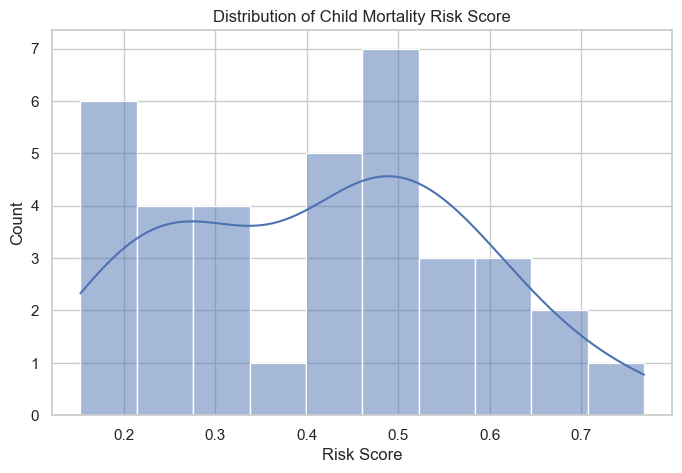

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df_weighted['weighted_risk_score'], bins=10, kde=True)

plt.title("Distribution of Child Mortality Risk Score")

plt.xlabel("Risk Score")

plt.savefig("../outputs/figures/distributions/nfhs_risk_score_distribution_v1.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Risk Category Count

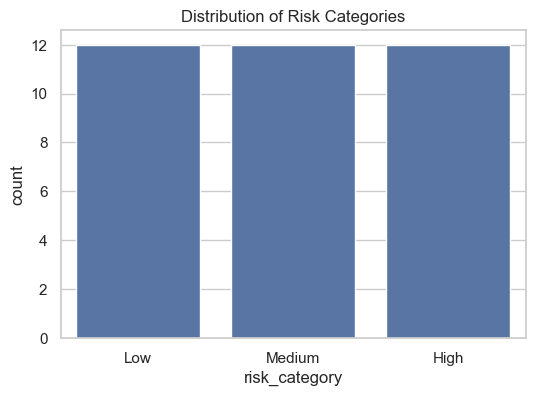

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_weighted, x='risk_category')

plt.title("Distribution of Risk Categories")

plt.savefig("../outputs/figures/distributions/nfhs_risk_category_count_v1.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Pairplot (Feature Relationships)

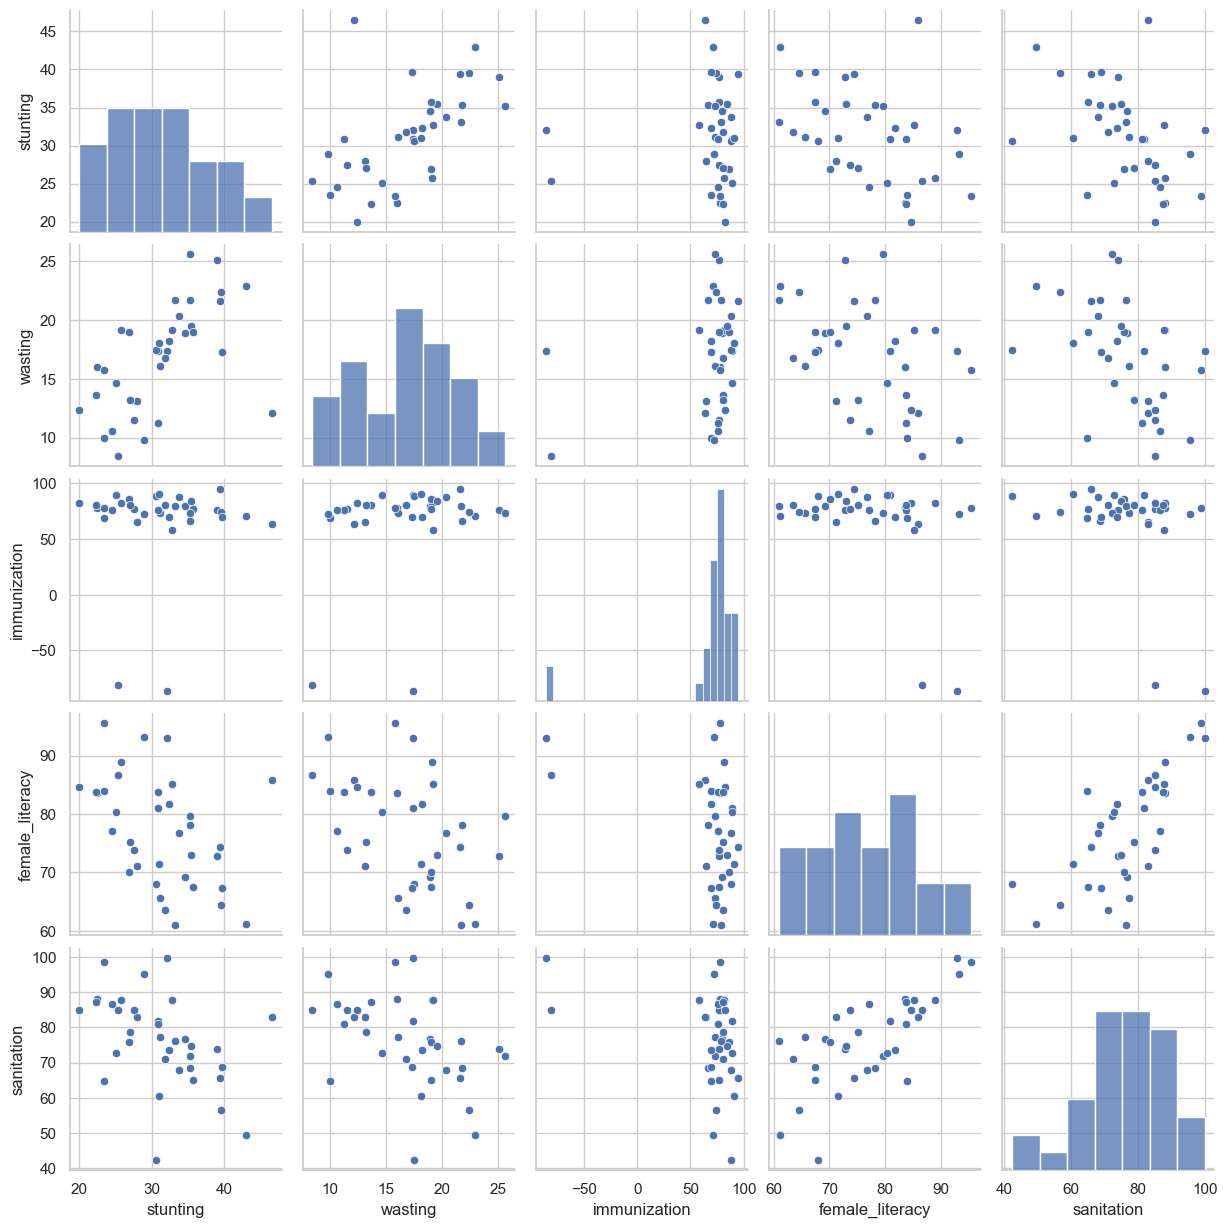

In [41]:
sns.pairplot(
    df,
    vars=['stunting', 'wasting', 'immunization', 'female_literacy', 'sanitation']
)

plt.savefig("../outputs/figures/relationships/nfhs_pairplot_v1.png",
            dpi=300,
            bbox_inches='tight')

plt.show()